# 1. INTRODUCTION (Markdown)
# Loan Risk Analysis Project
#Goal: Analyze loan data to identify default drivers and customer risk patterns.

## Dataset Overview

- Records: 9,578
- Features: 14
- Target Variable: not_fully_paid
- Domain: Banking / Loan Risk Analysis

**Objective:** Analyze customer credit behavior and identify factors influencing loan default.

# 2. DATA LOADING & UNDERSTANDING

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("loan_data.csv")

In [3]:
df.columns = df.columns.str.replace('.', '_')

In [4]:
df.head()

,credit_policy,purpose,int_rate,installment,log_annual_inc,dti,fico,days_with_cr_line,revol_bal,revol_util,inq_last_6mths,delinq_2yrs,pub_rec,not_fully_paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [5]:
df.shape

(9578, 14)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit_policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int_rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log_annual_inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days_with_cr_line  9578 non-null   float64
 8   revol_bal          9578 non-null   int64  
 9   revol_util         9578 non-null   float64
 10  inq_last_6mths     9578 non-null   int64  
 11  delinq_2yrs        9578 non-null   int64  
 12  pub_rec            9578 non-null   int64  
 13  not_fully_paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1010.2+ KB


In [7]:
df.columns

Index(['credit_policy', 'purpose', 'int_rate', 'installment', 'log_annual_inc',
       'dti', 'fico', 'days_with_cr_line', 'revol_bal', 'revol_util',
       'inq_last_6mths', 'delinq_2yrs', 'pub_rec', 'not_fully_paid'],
      dtype='object')

In [8]:
df.describe()

,credit_policy,int_rate,installment,log_annual_inc,dti,fico,days_with_cr_line,revol_bal,revol_util,inq_last_6mths,delinq_2yrs,pub_rec,not_fully_paid
count,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9.578000e+03,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000
mean,0.804970,0.122640,319.089413,10.932117,12.606679,710.846314,4560.767197,1.691396e+04,46.799236,1.577469,0.163708,0.062122,0.160054
std,0.396245,0.026847,207.071301,0.614813,6.883970,37.970537,2496.930377,3.375619e+04,29.014417,2.200245,0.546215,0.262126,0.366676
min,0.000000,0.060000,15.670000,7.547502,0.000000,612.000000,178.958333,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.103900,163.770000,10.558414,7.212500,682.000000,2820.000000,3.187000e+03,22.600000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.122100,268.950000,10.928884,12.665000,707.000000,4139.958333,8.596000e+03,46.300000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,0.140700,432.762500,11.291293,17.950000,737.000000,5730.000000,1.824950e+04,70.900000,2.000000,0.000000,0.000000,0.000000
max,1.000000,0.216400,940.140000,14.528354,29.960000,827.000000,17639.958330,1.207359e+06,119.000000,33.000000,13.000000,5.000000,1.000000


# 3. DATA CLEANING

In [10]:
df.isnull().sum()

credit_policy        0
purpose              0
int_rate             0
installment          0
log_annual_inc       0
dti                  0
fico                 0
days_with_cr_line    0
revol_bal            0
revol_util           0
inq_last_6mths       0
delinq_2yrs          0
pub_rec              0
not_fully_paid       0
dtype: int64

In [11]:
df.isnull().sum().sort_values(ascending=False)

credit_policy        0
purpose              0
int_rate             0
installment          0
log_annual_inc       0
dti                  0
fico                 0
days_with_cr_line    0
revol_bal            0
revol_util           0
inq_last_6mths       0
delinq_2yrs          0
pub_rec              0
not_fully_paid       0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df = df.drop_duplicates()

In [14]:
df.shape

(9578, 14)

In [15]:
df.dtypes

credit_policy          int64
purpose               object
int_rate             float64
installment          float64
log_annual_inc       float64
dti                  float64
fico                   int64
days_with_cr_line    float64
revol_bal              int64
revol_util           float64
inq_last_6mths         int64
delinq_2yrs            int64
pub_rec                int64
not_fully_paid         int64
dtype: object

4.EXPLORATORY DATA ANALYSIS(EDA)

In [17]:
df['fico'].describe()

df['dti'].describe()

count    9578.000000
mean       12.606679
std         6.883970
min         0.000000
25%         7.212500
50%        12.665000
75%        17.950000
max        29.960000
Name: dti, dtype: float64

How many customers default vs fully paid?

In [18]:
df['not_fully_paid'].value_counts()

not_fully_paid
0    8045
1    1533
Name: count, dtype: int64

Percentage view (better for interview)

In [19]:
df['not_fully_paid'].value_counts(normalize=True) * 100

not_fully_paid
0    83.994571
1    16.005429
Name: proportion, dtype: float64

Count loan types

In [20]:
df['purpose'].value_counts()

purpose
debt_consolidation    3957
all_other             2331
credit_card           1262
home_improvement       629
small_business         619
major_purchase         437
educational            343
Name: count, dtype: int64

Percentage view

In [21]:
df['purpose'].value_counts(normalize=True) * 100

purpose
debt_consolidation    41.313427
all_other             24.337022
credit_card           13.176028
home_improvement       6.567133
small_business         6.462727
major_purchase         4.562539
educational            3.581123
Name: proportion, dtype: float64

5.DATA VISUALIZATION


FICO Score Distribution

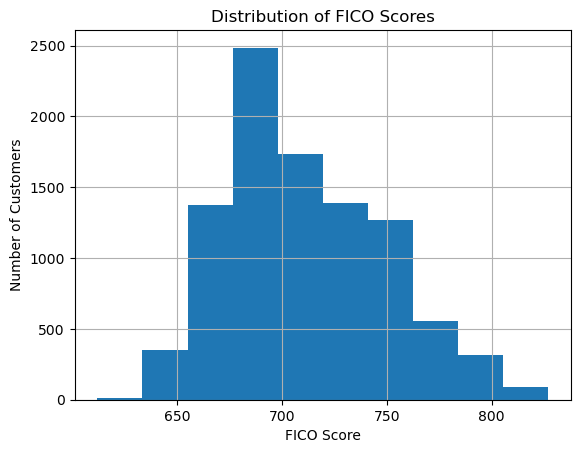

In [33]:
df['fico'].hist()

plt.title("Distribution of FICO Scores")
plt.xlabel("FICO Score")
plt.ylabel("Number of Customers")
plt.show()

DTI Distribution

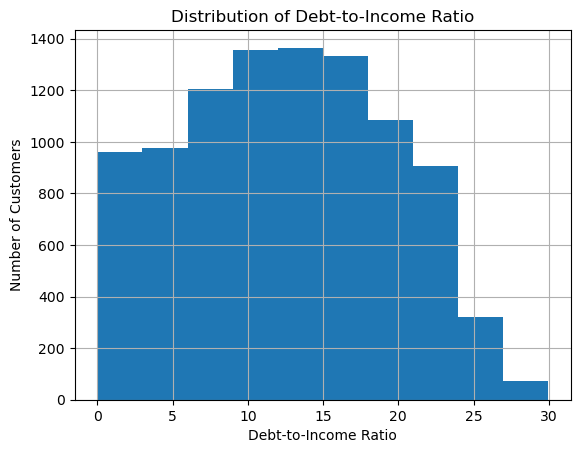

In [34]:
df['dti'].hist()

plt.title("Distribution of Debt-to-Income Ratio")
plt.xlabel("Debt-to-Income Ratio")
plt.ylabel("Number of Customers")
plt.show()

Interest Rate Analysis

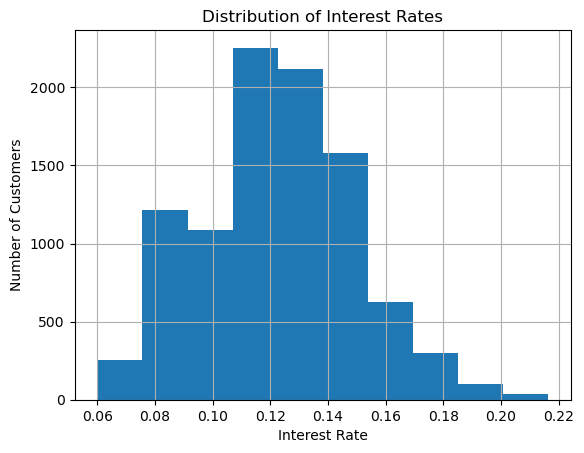

In [35]:
df['int_rate'].hist()

plt.title("Distribution of Interest Rates")
plt.xlabel("Interest Rate")
plt.ylabel("Number of Customers")
plt.show()

Loan Purpose Analysis

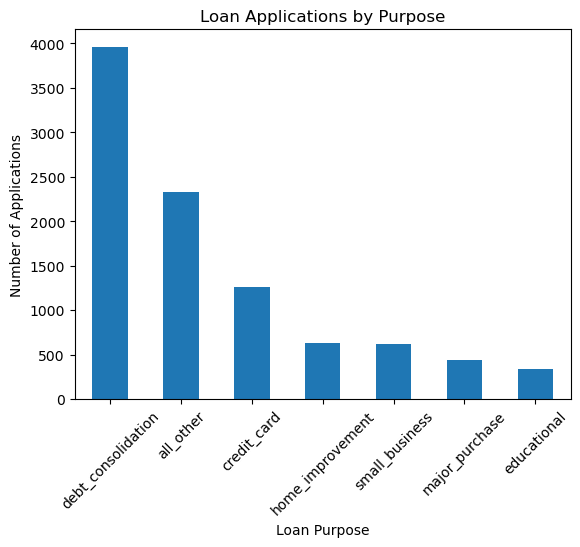

In [36]:
df['purpose'].value_counts().plot(kind='bar')

plt.title("Loan Applications by Purpose")
plt.xlabel("Loan Purpose")
plt.ylabel("Number of Applications")
plt.xticks(rotation=45)
plt.show()

Percentage view

Default Rate by Purpose

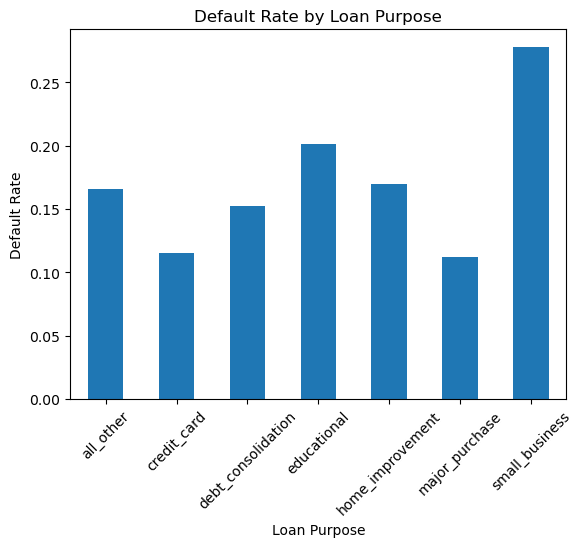

In [37]:
df.groupby('purpose')['not_fully_paid'].mean().plot(kind='bar')

plt.title("Default Rate by Loan Purpose")
plt.xlabel("Loan Purpose")
plt.ylabel("Default Rate")
plt.xticks(rotation=45)
plt.show()

Correlation Matrix

In [29]:
df.corr(numeric_only=True)

,credit_policy,int_rate,installment,log_annual_inc,dti,fico,days_with_cr_line,revol_bal,revol_util,inq_last_6mths,delinq_2yrs,pub_rec,not_fully_paid
credit_policy,1.000000,-0.294089,0.058770,0.034906,-0.090901,0.348319,0.099026,-0.187518,-0.104095,-0.535511,-0.076318,-0.054243,-0.158119
int_rate,-0.294089,1.000000,0.276140,0.056383,0.220006,-0.714821,-0.124022,0.092527,0.464837,0.202780,0.156079,0.098162,0.159552
installment,0.058770,0.276140,1.000000,0.448102,0.050202,0.086039,0.183297,0.233625,0.081356,-0.010419,-0.004368,-0.032760,0.049955
log_annual_inc,0.034906,0.056383,0.448102,1.000000,-0.054065,0.114576,0.336896,0.372140,0.054881,0.029171,0.029203,0.016506,-0.033439
dti,-0.090901,0.220006,0.050202,-0.054065,1.000000,-0.241191,0.060101,0.188748,0.337109,0.029189,-0.021792,0.006209,0.037362
fico,0.348319,-0.714821,0.086039,0.114576,-0.241191,1.000000,0.263880,-0.015553,-0.541289,-0.185293,-0.216340,-0.147592,-0.149666
days_with_cr_line,0.099026,-0.124022,0.183297,0.336896,0.060101,0.263880,1.000000,0.229344,-0.024239,-0.041736,0.081374,0.071826,-0.029237
revol_bal,-0.187518,0.092527,0.233625,0.372140,0.188748,-0.015553,0.229344,1.000000,0.203779,0.022394,-0.033243,-0.031010,0.053699
revol_util,-0.104095,0.464837,0.081356,0.054881,0.337109,-0.541289,-0.024239,0.203779,1.000000,-0.013880,-0.042740,0.066717,0.082088
inq_last_6mths,-0.535511,0.202780,-0.010419,0.029171,0.029189,-0.185293,-0.041736,0.022394,-0.013880,1.000000,0.021245,0.072673,0.149452


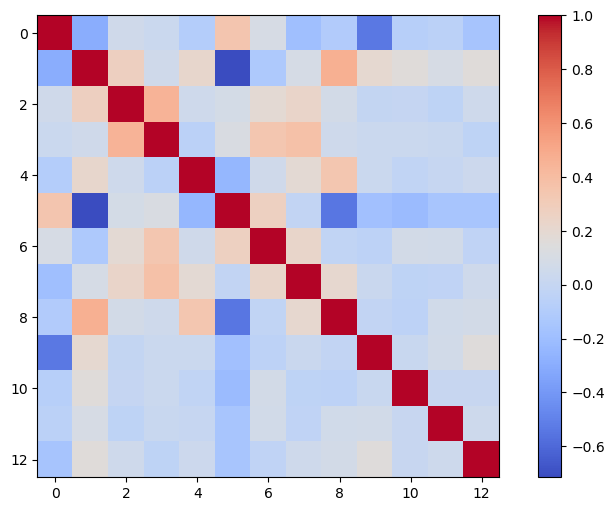

In [39]:
plt.figure(figsize=(10,6))
plt.imshow(df.corr(numeric_only=True), cmap='coolwarm')
plt.colorbar()
plt.show()

Default vs FICO Comparison

In [31]:

df.groupby('not_fully_paid')['fico'].mean()

not_fully_paid
0    713.326911
1    697.828441
Name: fico, dtype: float64

Default vs DTI Comparison

In [32]:
df.groupby('not_fully_paid')['dti'].mean()

not_fully_paid
0    12.494413
1    13.195838
Name: dti, dtype: float64

# Key Insights

- FICO strongly impacts default risk.
- High DTI increases probability of default.
- Small business loans are the highest-risk segment.
- Revolving utilization is positively correlated with default.

# Project Summary

This notebook demonstrates an end-to-end loan risk analysis workflow, including data loading, cleaning, exploratory data analysis (EDA), visualization, and business insights. The findings can help financial institutions understand customer risk profiles and support data-driven lending decisions.

# Conclusion

This project analyzed 9,578 loan applications to identify the major drivers of loan default.
The analysis showed that lower FICO scores, higher debt-to-income ratios, and small business loans are associated with increased default risk.
These insights can help financial institutions improve credit risk assessment and lending decisions.